<a href="https://colab.research.google.com/github/ANUPAM7209/machine-learning/blob/main/Standarzation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(style='whitegrid')

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df = df.iloc[:,2:]

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
112,38,61000,0
279,50,36000,1
348,39,77000,0
211,52,150000,1
354,36,99000,1


#Train Test split

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased', axis=1),
                                                 df['Purchased'], test_size=0.3,random_state=42)

In [7]:
X_test.shape , X_train.shape

((120, 2), (280, 2))

#Standard Scaler

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_test)
X_train_s = sc.transform(X_train)
X_test_s = sc.transform(X_test)

In [9]:
sc.mean_ , sc.var_

(array([3.78416667e+01, 6.77666667e+04]),
 array([1.23633264e+02, 1.18051222e+09]))

In [10]:
X_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [11]:
X_train_s

array([[-0.79518187,  0.21052479],
       [ 0.01423983,  0.35604883],
       [ 0.64379004, -1.21561086],
       [ 1.45321173,  1.17098349],
       [ 0.73372578, -1.30292529],
       [-1.33479634, -1.15740124],
       [-0.07569592,  0.21052479],
       [ 0.3739828 , -0.08052331],
       [-0.25556741,  0.09410555],
       [ 1.1834045 ,  2.27696624],
       [ 0.10417557,  0.82172578],
       [-1.24486059,  0.61799211],
       [ 1.81295471,  0.79262097],
       [-1.15492485, -1.3320301 ],
       [ 0.28404706, -0.25515216],
       [-0.88511762,  0.61799211],
       [ 0.3739828 ,  0.35604883],
       [ 0.3739828 ,  1.17098349],
       [ 0.73372578,  0.82172578],
       [ 0.82366152,  1.31650753],
       [-0.43543889, -1.15740124],
       [-1.69453931, -1.24471567],
       [ 1.00353301,  0.61799211],
       [-0.61531038, -1.53576376],
       [-0.70524613,  0.32694402],
       [ 0.91359727,  2.13144219],
       [-0.52537464,  1.43292677],
       [-0.07569592,  0.09410555],
       [-1.78447506,

In [12]:
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_test_s = pd.DataFrame(X_test_s , columns=X_test.columns)

In [13]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [14]:
np.round(X_train_s.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.1
std,0.9,1.0
min,-1.8,-1.5
25%,-0.7,-0.7
50%,-0.1,0.1
75%,0.6,0.6
max,2.0,2.4


# Effect of Scaling

Text(0.5, 1.0, 'After Scaling')

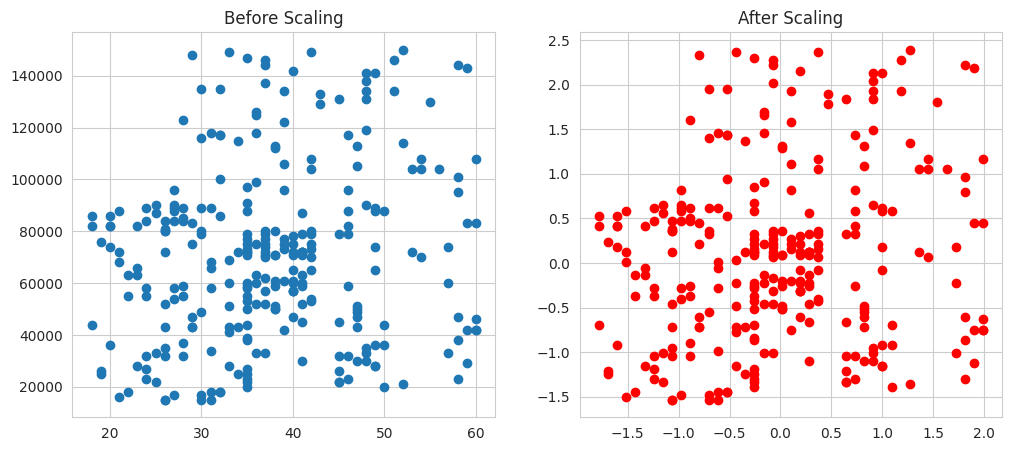

In [15]:
fig , (ax1,ax2) = plt.subplots(ncols= 2 , figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_s['Age'], X_train_s['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')

<Axes: title={'center': 'After_scaling'}, xlabel='Age', ylabel='Density'>

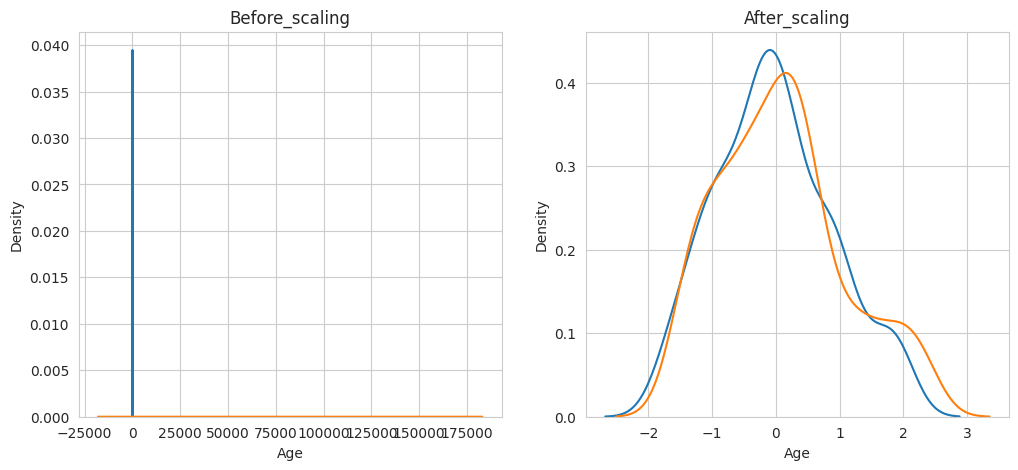

In [16]:
fig ,(ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.set_title('Before_scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

ax2.set_title('After_scaling')
sns.kdeplot(X_train_s['Age'], ax=ax2)
sns.kdeplot(X_train_s['EstimatedSalary'], ax=ax2)

#Comparision

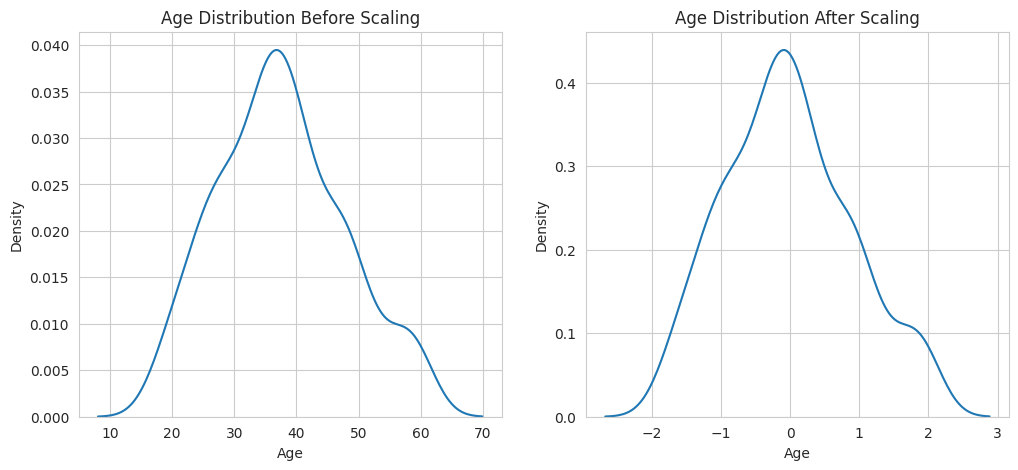

In [17]:
fig , (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

ax2.set_title('Age Distribution After Scaling')
sns.kdeplot(X_train_s['Age'], ax=ax2)
plt.show()

#Why Scaling is important?

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
lr = LogisticRegression()
lr_s = LogisticRegression()

In [20]:
lr.fit(X_train,y_train)
lr_s.fit(X_train_s , y_train)

LogisticRegression()

In [21]:
y_pred = lr.predict(X_test)
y_pred_s = lr.predict(X_test_s)

In [22]:
from sklearn.metrics import  accuracy_score

In [23]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled" , accuracy_score(y_test,y_pred_s))

Actual 0.85
Scaled 0.6083333333333333


In [24]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [26]:
new_df = pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,25000,35000],'Purchased':[0,1,1]})
df = pd.concat([df, new_df], ignore_index=True)

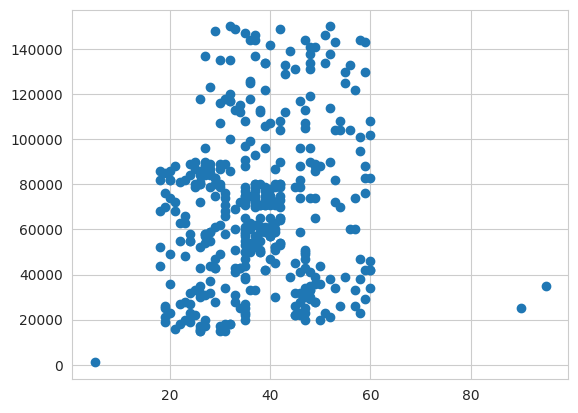

In [27]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [28]:
X_train , X_test , y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                      df['Purchased'],
                                                      test_size=0.3,
                                                      random_state=42)
X_train.shape , X_test.shape


((282, 2), (121, 2))

In [29]:
scal = StandardScaler()

scal.fit(X_train)
X_train_ss = scal.transform(X_train)
X_test_ss = scal.transform(X_test)

In [32]:
X_train_ss = pd.DataFrame(X_train_ss , columns = X_train.columns)
X_test_ss = pd.DataFrame(X_test_ss , columns = X_test.columns)

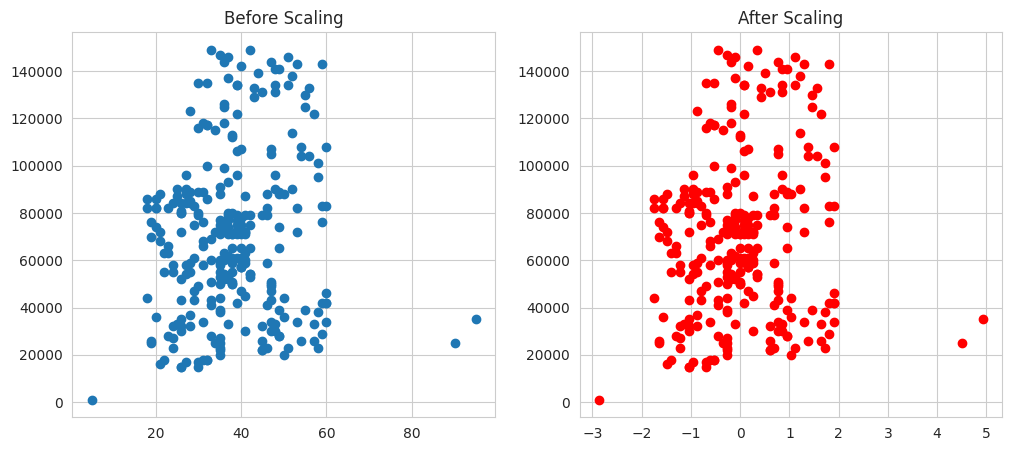

In [36]:
fig , (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_ss['Age'],X_train['EstimatedSalary'], color= 'red')
ax2.set_title("After Scaling")

plt.show()